In [1]:
import rasterio
import numpy as np

# ============================================================
# 1. MODIS LST file
# ============================================================
modis_path = "/scratch/alpine/battobrah@xsede.org/HB_NMP_full_domain_comparison_data/MODIS_LST_2014_2024/MOD11A1_monthly_mean_2014_01.tif"

with rasterio.open(modis_path) as src:
    print("=== MODIS MOD11A1 ===")
    print(f"CRS: {src.crs}")
    print(f"Transform: {src.transform}")
    print(f"Resolution (x, y): {src.res}")
    print(f"Shape (height, width): {src.shape}")
    print(f"Bounds: {src.bounds}")
    print(f"Dtype: {src.dtypes}")
    print(f"Nodata: {src.nodata}")

# ============================================================
# 2. HydroBlocks domain raster (hrus.vrt or cids.vrt)
# ============================================================
hb_path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_100hru_full_domain_downscaled/postprocess/hrus.vrt"

with rasterio.open(hb_path) as src:
    print("\n=== HydroBlocks (hrus.vrt) ===")
    print(f"CRS: {src.crs}")
    print(f"Transform: {src.transform}")
    print(f"Resolution (x, y): {src.res}")
    print(f"Shape (height, width): {src.shape}")
    print(f"Bounds: {src.bounds}")
    print(f"Dtype: {src.dtypes}")
    print(f"Nodata: {src.nodata}")

=== MODIS MOD11A1 ===
CRS: EPSG:4326
Transform: | 0.01, 0.00,-114.01|
| 0.00,-0.01, 44.12|
| 0.00, 0.00, 1.00|
Resolution (x, y): (0.008983152841195215, 0.008983152841195215)
Shape (height, width): (1127, 1114)
Bounds: BoundingBox(left=-114.00519270760847, bottom=33.992250351082696, right=-103.997960442517, top=44.1162636031097)
Dtype: ('float64', 'float64')
Nodata: None

=== HydroBlocks (hrus.vrt) ===
CRS: EPSG:4326
Transform: | 0.00, 0.00,-114.25|
| 0.00,-0.00, 44.25|
| 0.00, 0.00, 1.00|
Resolution (x, y): (0.0008333333333333041, 0.0008333333333333041)
Shape (height, width): (12601, 12601)
Bounds: BoundingBox(left=-114.25041666666561, bottom=33.74958333333305, right=-103.74958333333265, top=44.25041666666601)
Dtype: ('float32',)
Nodata: -9999.0


In [1]:
import rasterio
import numpy as np

# ============================================================
# 1. SMAP soil moisture file
# ============================================================
smap_path = "/scratch/alpine/battobrah@xsede.org/HB_NMP_full_domain_comparison_data/SMAP_0779_2015_2024_full domain/NSIDC-0779_EASE2_G1km_SMAP_SM_DS_20150401.tif"

with rasterio.open(smap_path) as src:
    print("=== SMAP NSIDC-0779 ===")
    print(f"CRS: {src.crs}")
    print(f"Transform: {src.transform}")
    print(f"Resolution (x, y): {src.res}")
    print(f"Shape (height, width): {src.shape}")
    print(f"Bounds: {src.bounds}")
    print(f"Dtype: {src.dtypes}")
    print(f"Nodata: {src.nodata}")

# ============================================================
# 2. HydroBlocks domain raster (hrus.vrt)
# ============================================================
hb_path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test/postprocess/hrus.vrt"



with rasterio.open(hb_path) as src:
    print("\n=== HydroBlocks (hrus.vrt) ===")
    print(f"CRS: {src.crs}")
    print(f"Transform: {src.transform}")
    print(f"Resolution (x, y): {src.res}")
    print(f"Shape (height, width): {src.shape}")
    print(f"Bounds: {src.bounds}")
    print(f"Dtype: {src.dtypes}")
    print(f"Nodata: {src.nodata}")

=== SMAP NSIDC-0779 ===
CRS: EPSG:6933
Transform: | 1000.90, 0.00,-17367530.45|
| 0.00,-1000.90, 7314540.79|
| 0.00, 0.00, 1.00|
Resolution (x, y): (1000.89502334956, 1000.89502334956)
Shape (height, width): (14616, 34704)
Bounds: BoundingBox(left=-17367530.44516138, bottom=-7314540.868694279, right=17367530.445161752, top=7314540.79258289)
Dtype: ('float32', 'float32')
Nodata: 0.0

=== HydroBlocks (hrus.vrt) ===
CRS: EPSG:4326
Transform: | 0.00, 0.00,-114.25|
| 0.00,-0.00, 44.25|
| 0.00, 0.00, 1.00|
Resolution (x, y): (0.0008333333333333041, 0.0008333333333333041)
Shape (height, width): (12601, 12601)
Bounds: BoundingBox(left=-114.25041666666561, bottom=33.74958333333305, right=-103.74958333333265, top=44.25041666666601)
Dtype: ('float32',)
Nodata: -9999.0


In [5]:
import glob
import os
import re
from datetime import datetime

import netCDF4 as nc
import numpy as np
import rasterio

# ---- Edit these for your run ----
EDIR = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test"
MODIS_DIR = "/scratch/alpine/battobrah@xsede.org/HB_NMP_full_domain_comparison_data/MODIS_LST_2014_2024"
START_YEAR = 2014
END_YEAR = 2024
VARIABLE = "trad"
DAY_COSZ = 0.3
N_FILES_TO_CHECK = 5

In [6]:
folder = os.path.join(os.path.abspath(EDIR), "postprocess", "output_dir")
files = []
for year in range(START_YEAR, END_YEAR + 1):
    files += sorted(glob.glob(os.path.join(folder, f"{year}????.nc")))

print(f"Folder: {folder}")
print(f"Total files found for {START_YEAR}-{END_YEAR}: {len(files)}")

expected_days = 0
for year in range(START_YEAR, END_YEAR + 1):
    expected_days += 366 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 365
print(f"Expected daily files if no gaps: {expected_days}  "
      f"({'OK' if len(files) == expected_days else 'MISMATCH -- possible missing days'})")

Folder: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test/postprocess/output_dir
Total files found for 2014-2024: 4015
Expected daily files if no gaps: 4018  (MISMATCH -- possible missing days)


In [1]:
sample_files = files[:1] + files[len(files)//2 : len(files)//2+1] + files[-1:]
sample_files = list(dict.fromkeys(sample_files))[:N_FILES_TO_CHECK]

for filename in sample_files:
    base = os.path.basename(filename)
    filename_date = datetime.strptime(base[:8], "%Y%m%d")
    print(f"\n=== {base} (filename implies {filename_date.date()}) ===")

    with nc.Dataset(filename) as ds:
        trad = ds.variables[VARIABLE]
        print(f"{VARIABLE} shape: {trad.shape}, dims: {trad.dimensions}")

        n_time = trad.shape[0]
        hours = np.arange(n_time, dtype=float) * 24.0 / n_time
        print(f"Implied UTC hours: {hours.tolist()}")

        for time_var_name in ("date", "time"):
            if time_var_name in ds.variables:
                tvar = ds.variables[time_var_name]
                units = getattr(tvar, "units", None)
                print(f"Found '{time_var_name}': units='{units}'")
                if units:
                    actual_dates = nc.num2date(
                        tvar[:2], units=units,
                        calendar=getattr(tvar, "calendar", "standard"),
                        only_use_cftime_datetimes=False, only_use_python_datetimes=True,
                    )
                    print(f"Decoded first timestamp(s): {actual_dates}")
                break
        else:
            print("No 'date' or 'time' variable found in this file.")

        data = np.ma.asarray(trad[:]).filled(np.nan).astype(float)
        finite = np.isfinite(data)
        in_range = finite & (data > 100.0) & (data < 400.0)
        n_finite = int(np.sum(finite))
        print(f"Finite: {n_finite}/{data.size} ({100*n_finite/data.size:.1f}%)")
        if n_finite:
            print(f"Within [100,400]K: {int(np.sum(in_range))}/{n_finite} "
                  f"({100*np.sum(in_range)/n_finite:.1f}%)")
            print(f"Value range: {np.nanmin(data):.2f} to {np.nanmax(data):.2f}")

        if "cosz" in ds.variables:
            cosz = np.ma.asarray(ds.variables["cosz"][:]).filled(np.nan).astype(float)
            cosz_finite = cosz[np.isfinite(cosz)]
            if cosz_finite.size:
                print(f"cosz range: {np.nanmin(cosz_finite):.3f} to {np.nanmax(cosz_finite):.3f}")
                out_of_range = int(np.sum((cosz_finite < -1.0001) | (cosz_finite > 1.0001)))
                if out_of_range:
                    print(f"!! {out_of_range} cosz values outside [-1,1]")
                n_day = int(np.sum(cosz_finite > DAY_COSZ))
                n_night = int(np.sum(cosz_finite < 0.0))
                print(f"cosz > {DAY_COSZ}: {100*n_day/cosz_finite.size:.1f}%   "
                      f"cosz < 0: {100*n_night/cosz_finite.size:.1f}%")
        else:
            print("No 'cosz' in this file -- fixed-UTC selection will be used.")

NameError: name 'files' is not defined

In [8]:
pattern = re.compile(r"MOD11A1_monthly_mean_(\d{4})_(\d{2})\.tif$")
modis_files = sorted(glob.glob(os.path.join(MODIS_DIR, "*.tif")))
matched = []
for f in modis_files:
    m = pattern.match(os.path.basename(f))
    if m:
        year, month = map(int, m.groups())
        if START_YEAR <= year <= END_YEAR:
            matched.append((f, year, month))

n_expected = 12 * (END_YEAR - START_YEAR + 1)
print(f"Matched MODIS files: {len(matched)} (expected {n_expected})")

present = {(y, m) for _, y, m in matched}
missing = [(y, m) for y in range(START_YEAR, END_YEAR+1) for m in range(1, 13) if (y, m) not in present]
print(f"Missing months: {missing if missing else 'none'}")

modis_sample_path = matched[0][0] if matched else None
if modis_sample_path:
    with rasterio.open(modis_sample_path) as src:
        print(f"\nSample: {os.path.basename(modis_sample_path)}")
        print(f"Bands: {src.count}, CRS: {src.crs}, Resolution: {src.res}, Shape: {src.shape}")
        for band in range(1, src.count + 1):
            data = src.read(band, masked=True).filled(np.nan).astype(float)
            finite = data[np.isfinite(data)]
            if finite.size:
                print(f"  Band {band}: median={np.nanmedian(finite):.2f}, "
                      f"range=({np.nanmin(finite):.2f}, {np.nanmax(finite):.2f})")

Matched MODIS files: 132 (expected 132)
Missing months: none

Sample: MOD11A1_monthly_mean_2014_01.tif
Bands: 2, CRS: EPSG:4326, Resolution: (0.008983152841195215, 0.008983152841195215), Shape: (1127, 1114)
  Band 1: median=2.31, range=(-20.53, 25.02)
  Band 2: median=-8.47, range=(-34.87, 10.27)


In [9]:
candidate_files = sorted(glob.glob(os.path.join(folder, f"{START_YEAR}????.nc")))
with nc.Dataset(candidate_files[0]) as ds:
    lon = np.asarray(ds.variables["lon"][:], dtype=float)
    lat = np.asarray(ds.variables["lat"][:], dtype=float)

hb_res_lon = float(np.abs(np.mean(np.diff(np.sort(lon)))))
hb_res_lat = float(np.abs(np.mean(np.diff(np.sort(lat)))))
print(f"HydroBlocks grid: {len(lat)}x{len(lon)}, resolution ~{hb_res_lat:.6f} x {hb_res_lon:.6f} deg")

if modis_sample_path:
    with rasterio.open(modis_sample_path) as src:
        print(f"MODIS grid: {src.height}x{src.width}, resolution {src.res[0]:.6f} x {src.res[1]:.6f} deg")

    ratio = hb_res_lon / src.res[0]
    if ratio > 1.05:
        print(f"\n--> HB grid is COARSER ({ratio:.2f}x). reproject() resamples MODIS DOWN onto HB's grid.")
    elif ratio < 0.95:
        print(f"\n--> HB grid is FINER ({ratio:.2f}x). reproject() upsamples MODIS via bilinear interpolation.")
    else:
        print(f"\n--> Grids are approximately equal resolution ({ratio:.2f}x).")

HydroBlocks grid: 630x630, resolution ~0.016667 x 0.016667 deg
MODIS grid: 1127x1114, resolution 0.008983 x 0.008983 deg

--> HB grid is COARSER (1.86x). reproject() resamples MODIS DOWN onto HB's grid.


In [3]:
import os
import glob
import numpy as np
import rasterio
import netCDF4 as nc

# ============================================================
# Paths
# ============================================================
smap_path = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HB_NMP_full_domain_comparison_data/"
    "SMAP_0779_2015_2024_full domain/"
    "NSIDC-0779_EASE2_G1km_SMAP_SM_DS_20150401.tif"
)

edir_3d = (
    "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/"
    "upper_colorado/experiments/simulations/"
    "MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_"
    "50hru_full_domain_downscaled_test"
)

hb_postprocess_dir = os.path.join(
    edir_3d,
    "postprocess",
    "output_dir"
)

# ============================================================
# 1. Inspect SMAP GeoTIFF
# ============================================================
print("=" * 70)
print("SMAP FILE")
print("=" * 70)
print("Path:", smap_path)

if not os.path.isfile(smap_path):
    raise FileNotFoundError(f"SMAP file does not exist:\n{smap_path}")

with rasterio.open(smap_path) as src:
    print("Driver:", src.driver)
    print("CRS:", src.crs)
    print("Transform:")
    print(src.transform)
    print("Resolution:", src.res)
    print("Shape:", src.shape)
    print("Bounds:", src.bounds)
    print("Number of bands:", src.count)
    print("Data types:", src.dtypes)
    print("Nodata:", src.nodata)
    print("Band descriptions:", src.descriptions)
    print("Dataset tags:", src.tags())

    for band_number in range(1, src.count + 1):
        band = src.read(band_number, masked=True)

        valid = band.compressed()

        print(f"\nSMAP band {band_number}")
        print("Description:", src.descriptions[band_number - 1])
        print("Band tags:", src.tags(band_number))
        print("Shape:", band.shape)
        print("Valid pixels:", valid.size)

        if valid.size > 0:
            print("Minimum:", np.min(valid))
            print("Maximum:", np.max(valid))
            print("Mean:", np.mean(valid))
            print("Median:", np.median(valid))
        else:
            print("No valid pixels found.")

# ============================================================
# 2. Find one HydroBlocks postprocessed NetCDF file
# ============================================================
print("\n" + "=" * 70)
print("HYDROBLOCKS POSTPROCESSED OUTPUT")
print("=" * 70)
print("Directory:", hb_postprocess_dir)

if not os.path.isdir(hb_postprocess_dir):
    raise NotADirectoryError(
        "HydroBlocks postprocessing directory does not exist:\n"
        f"{hb_postprocess_dir}"
    )

hb_files = sorted(
    glob.glob(os.path.join(hb_postprocess_dir, "*.nc"))
)

print("Number of postprocessed NetCDF files:", len(hb_files))

if not hb_files:
    raise FileNotFoundError(
        "No NetCDF files were found in:\n"
        f"{hb_postprocess_dir}"
    )

hb_file = hb_files[0]

print("First file:", hb_file)
print("File size:", os.path.getsize(hb_file) / 1024**2, "MB")

# ============================================================
# 3. Inspect the HydroBlocks NetCDF structure
# ============================================================
with nc.Dataset(hb_file, "r") as ds:
    print("\nNetCDF format:", ds.file_format)

    print("\nDimensions:")
    for name, dimension in ds.dimensions.items():
        print(
            f"  {name}: size={len(dimension)}, "
            f"unlimited={dimension.isunlimited()}"
        )

    print("\nRoot-level variables:")
    for name, variable in ds.variables.items():
        print(
            f"  {name}: dimensions={variable.dimensions}, "
            f"shape={variable.shape}, dtype={variable.dtype}"
        )

        if hasattr(variable, "units"):
            print(f"      units={variable.units}")

        if hasattr(variable, "long_name"):
            print(f"      long_name={variable.long_name}")

        if hasattr(variable, "description"):
            print(f"      description={variable.description}")

    print("\nGroups:", list(ds.groups.keys()))

    for group_name, group in ds.groups.items():
        print(f"\nGroup: {group_name}")

        for name, variable in group.variables.items():
            print(
                f"  {name}: dimensions={variable.dimensions}, "
                f"shape={variable.shape}, dtype={variable.dtype}"
            )

# ============================================================
# 4. Locate and inspect SMC
# ============================================================
print("\n" + "=" * 70)
print("HYDROBLOCKS SMC VARIABLE")
print("=" * 70)

with nc.Dataset(hb_file, "r") as ds:
    smc_variable = None
    smc_location = None

    # Check root level
    if "smc" in ds.variables:
        smc_variable = ds.variables["smc"]
        smc_location = "root"

    # Check groups
    if smc_variable is None:
        for group_name, group in ds.groups.items():
            if "smc" in group.variables:
                smc_variable = group.variables["smc"]
                smc_location = f"group '{group_name}'"
                break

    if smc_variable is None:
        raise KeyError(
            "The variable 'smc' was not found in the root or any group."
        )

    print("SMC location:", smc_location)
    print("SMC dimensions:", smc_variable.dimensions)
    print("SMC shape:", smc_variable.shape)
    print("SMC dtype:", smc_variable.dtype)
    print("SMC units:", getattr(smc_variable, "units", "not provided"))
    print(
        "SMC fill value:",
        getattr(smc_variable, "_FillValue", "not provided")
    )

    # Read as a masked array so _FillValue is respected
    smc = smc_variable[:]

    # Convert masked and fill values to NaN
    if np.ma.isMaskedArray(smc):
        smc = smc.filled(np.nan)

    smc = np.asarray(smc, dtype=np.float32)

    # Remove extremely large fill values if still present
    smc[np.abs(smc) > 1.0e5] = np.nan

    print("Valid SMC values:", np.count_nonzero(np.isfinite(smc)))

    if np.any(np.isfinite(smc)):
        print("SMC minimum:", np.nanmin(smc))
        print("SMC maximum:", np.nanmax(smc))
        print("SMC mean:", np.nanmean(smc))

    # ========================================================
    # Determine axes using dimension names
    # ========================================================
    dimension_names = [
        name.lower() for name in smc_variable.dimensions
    ]

    time_names = {"time", "t"}
    soil_names = {
        "soil",
        "soil_layer",
        "soil_layers",
        "layer",
        "layers",
        "nsoil"
    }

    time_axis = next(
        (
            i for i, name in enumerate(dimension_names)
            if name in time_names
        ),
        None
    )

    soil_axis = next(
        (
            i for i, name in enumerate(dimension_names)
            if name in soil_names
        ),
        None
    )

    print("\nDetected time axis:", time_axis)
    print("Detected soil-layer axis:", soil_axis)

    # ========================================================
    # Select top soil layer
    # ========================================================
    smc_top = smc

    if soil_axis is not None:
        smc_top = np.take(
            smc_top,
            indices=0,
            axis=soil_axis
        )

        # Removing soil axis can shift the time-axis position
        if time_axis is not None and soil_axis < time_axis:
            time_axis -= 1

    print("Top-layer SMC shape:", smc_top.shape)

    # ========================================================
    # Calculate daily mean from time steps in this file
    # ========================================================
    if time_axis is not None:
        hb_daily_smc = np.nanmean(
            smc_top,
            axis=time_axis
        )
    else:
        hb_daily_smc = smc_top

    print("Daily top-layer SMC shape:", hb_daily_smc.shape)
    print(
        "Daily valid pixels:",
        np.count_nonzero(np.isfinite(hb_daily_smc))
    )

    if np.any(np.isfinite(hb_daily_smc)):
        print(
            "Daily top-layer SMC minimum:",
            np.nanmin(hb_daily_smc)
        )
        print(
            "Daily top-layer SMC maximum:",
            np.nanmax(hb_daily_smc)
        )
        print(
            "Daily top-layer SMC mean:",
            np.nanmean(hb_daily_smc)
        )

print("\nInspection completed successfully.")

SMAP FILE
Path: /scratch/alpine/battobrah@xsede.org/HB_NMP_full_domain_comparison_data/SMAP_0779_2015_2024_full domain/NSIDC-0779_EASE2_G1km_SMAP_SM_DS_20150401.tif
Driver: GTiff
CRS: EPSG:6933
Transform:
| 1000.90, 0.00,-17367530.45|
| 0.00,-1000.90, 7314540.79|
| 0.00, 0.00, 1.00|
Resolution: (1000.89502334956, 1000.89502334956)
Shape: (14616, 34704)
Bounds: BoundingBox(left=-17367530.44516138, bottom=-7314540.868694279, right=17367530.445161752, top=7314540.79258289)
Number of bands: 2
Data types: ('float32', 'float32')
Nodata: 0.0
Band descriptions: (None, None)
Dataset tags: {'AREA_OR_POINT': 'Area'}

SMAP band 1
Description: None
Band tags: {}
Shape: (14616, 34704)
Valid pixels: 507233664
Minimum: nan
Maximum: nan
Mean: nan
Median: nan

SMAP band 2
Description: None
Band tags: {}
Shape: (14616, 34704)
Valid pixels: 507233664
Minimum: nan
Maximum: nan
Mean: nan
Median: nan

HYDROBLOCKS POSTPROCESSED OUTPUT
Directory: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado

/projects/battobrah@xsede.org/code-server/tmp/ipykernel_828434/2446283526.py:261: RuntimeWarning: Mean of empty slice
  hb_daily_smc = np.nanmean(


In [2]:
import glob
import netCDF4 as nc
import os

path_3d = (
    "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/"
    "upper_colorado/experiments/simulations/"
    "MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_"
    "full_domain_downscaled_test"
)

cid = 1

input_file = os.path.join(path_3d, str(cid), "input_file.nc")

output_files = sorted(
    glob.glob(os.path.join(path_3d, "output_data", str(cid), "*.nc"))
)

if not output_files:
    raise FileNotFoundError(
        f"No model output NetCDF files found for CID {cid}"
    )

output_file = output_files[0]

def list_nc_vars(path):
    print(f"\n--- File: {path} ---")
    with nc.Dataset(path) as ds:
        for gname, grp in ds.groups.items():
            print(f"\n[Group: {gname}]")
            for vname, var in grp.variables.items():
                print(
                    f"  {vname:20s} "
                    f"shape={var.shape} "
                    f"dims={var.dimensions}"
                )

list_nc_vars(input_file)
list_nc_vars(output_file)


--- File: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test/1/input_file.nc ---

[Group: meteorology]
  lwdown               shape=(32120, 50) dims=('time', 'hru')
  swdown               shape=(32120, 50) dims=('time', 'hru')
  tair                 shape=(32120, 50) dims=('time', 'hru')
  precip               shape=(32120, 50) dims=('time', 'hru')
  psurf                shape=(32120, 50) dims=('time', 'hru')
  wind                 shape=(32120, 50) dims=('time', 'hru')
  spfh                 shape=(32120, 50) dims=('time', 'hru')
  time                 shape=(32120,) dims=('time',)

[Group: water_use]

[Group: metadata]

[Group: wmatrix_Basin1]
  data                 shape=(4,) dims=('connections_columns',)
  indices              shape=(4,) dims=('connections_columns',)
  indptr               shape=(3,) dims=('connections_rows',)

[Group: wmatrix_Basin2]
  data        

In [1]:
import argparse
import glob
import importlib
import os
import sys

import numpy as np


# ============================================================
# 1. Locate and import the existing plotting script
# ============================================================

REPO = "/home/battobrah@xsede.org/HydroBlocks_Enrico_dev"

if REPO not in sys.path:
    sys.path.insert(0, REPO)

candidates = sorted(
    glob.glob(
        os.path.join(
            REPO,
            "plot_seasonal_3d_minus_pp*.py",
        )
    ),
    key=os.path.getmtime,
    reverse=True,
)

valid_scripts = []

for path in candidates:
    with open(path, "r", encoding="utf-8") as stream:
        text = stream.read()

    if (
        "def read_seasonal_means" in text
        and "VARIABLES" in text
        and "SNOW_MASKED_VARIABLES" in text
    ):
        valid_scripts.append(path)

if not valid_scripts:
    print("Candidate files found:")

    for path in candidates:
        print(path)

    raise FileNotFoundError(
        "Could not find the seasonal 3D-minus-PP plotting script."
    )

SCRIPT_PATH = valid_scripts[0]
MODULE_NAME = os.path.splitext(os.path.basename(SCRIPT_PATH))[0]

paired = importlib.import_module(MODULE_NAME)

print("Loaded plotting script:")
print(SCRIPT_PATH)


# ============================================================
# 2. Set experiment paths and calculation options
# ============================================================

args = argparse.Namespace(
    edir_3d=(
        "/scratch/alpine/battobrah@xsede.org/"
        "Rice_NMT_Snow/upper_colorado/"
        "experiments/simulations/"
        "MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_"
        "50hru_full_domain_downscaled_test"
    ),
    edir_pp=(
        "/scratch/alpine/battobrah@xsede.org/"
        "Rice_NMT_Snow/upper_colorado/"
        "experiments/simulations/"
        "MSWX_3h_Snow_Project3_pp_upper_colorado_11yr_"
        "50hru_full_domain_downscaled_test"
    ),
    start_year=2014,
    end_year=2024,
    workers=6,
    soil_layer=0,
)


# ============================================================
# 3. Select variables
# ============================================================

requested_variables = [
    "fsno",
    "swe",
]

# FSNO must be loaded when checking SWE so that the same annual
# snow mask used by the plotting script is also applied here.
variables_to_read = requested_variables.copy()

if any(
    name in paired.SNOW_MASKED_VARIABLES
    for name in requested_variables
):
    if "fsno" not in variables_to_read:
        variables_to_read.append("fsno")

available_names = {
    specification["name"]
    for specification in paired.VARIABLES
}

missing_names = set(variables_to_read) - available_names

if missing_names:
    raise ValueError(
        f"Variables not defined in plotting script: "
        f"{sorted(missing_names)}"
    )

specifications = tuple(
    specification
    for specification in paired.VARIABLES
    if specification["name"] in variables_to_read
)

print("\nVariables being read:")
print([item["name"] for item in specifications])


# ============================================================
# 4. Calculate the seasonal mean fields
# ============================================================

lon, lat, seasonal = paired.read_seasonal_means(
    args,
    specifications,
)

print("\nGrid:")
print(f"Longitude cells: {len(lon):,}")
print(f"Latitude cells:  {len(lat):,}")


# ============================================================
# 5. Print seasonal and overall min/max differences
# ============================================================

print("\n")
print("=" * 90)
print("SEASONAL 3D − PP DIFFERENCE RANGES")
print("=" * 90)

results = []

for name in requested_variables:
    combined_values = []

    print(f"\nVariable: {name}")
    print("-" * 90)

    for season in paired.SEASONS:
        difference = seasonal[name][season]["difference"]

        values = np.asarray(
            difference[np.isfinite(difference)],
            dtype=float,
        )

        if values.size == 0:
            print(
                f"{season:8s}: no valid values"
            )
            continue

        minimum = float(np.min(values))
        maximum = float(np.max(values))
        symmetric_limit = max(
            abs(minimum),
            abs(maximum),
        )

        print(
            f"{season:8s}: "
            f"min = {minimum:12.6g}, "
            f"max = {maximum:12.6g}, "
            f"symmetric colorbar = ±{symmetric_limit:.6g}, "
            f"n = {values.size:,}"
        )

        results.append(
            {
                "variable": name,
                "season": season,
                "minimum": minimum,
                "maximum": maximum,
                "symmetric_limit": symmetric_limit,
                "n": values.size,
            }
        )

        combined_values.append(values)

    if combined_values:
        combined = np.concatenate(combined_values)

        overall_minimum = float(np.min(combined))
        overall_maximum = float(np.max(combined))
        overall_symmetric_limit = max(
            abs(overall_minimum),
            abs(overall_maximum),
        )

        print("-" * 90)
        print(
            f"{'OVERALL':8s}: "
            f"min = {overall_minimum:12.6g}, "
            f"max = {overall_maximum:12.6g}, "
            f"symmetric colorbar = "
            f"±{overall_symmetric_limit:.6g}, "
            f"n = {combined.size:,}"
        )

        results.append(
            {
                "variable": name,
                "season": "OVERALL",
                "minimum": overall_minimum,
                "maximum": overall_maximum,
                "symmetric_limit": overall_symmetric_limit,
                "n": combined.size,
            }
        )


# ============================================================
# 6. Display results as a table
# ============================================================

try:
    import pandas as pd

    results_table = pd.DataFrame(results)

    display(results_table)

except ImportError:
    results_table = results

Loaded plotting script:
/home/battobrah@xsede.org/HydroBlocks_Enrico_dev/plot_seasonal_3d_minus_pp_parallel.py

Variables being read:
['swe', 'fsno']
Matched days: 4015; missing from 3D: 0; missing from PP: 0
Daily-file readers: 6; chunks: 24; approximately 168 days/chunk


KeyboardInterrupt: 

3D shape: (32120, 50)
PP shape: (32120, 50)
Terrain HRUs: 50
Total time steps: 32120
Winter time steps: 7920
First time: 2014-01-01 00:00:00
Last time: 2024-12-28 21:00:00

Terrain diagnostics
Slope range: 0.008402745239436626 0.2759917378425598
East-west range: -0.06836704852399128 0.06198037182366891
North-south range: -0.08329293771658183 0.05037134461926176
trad difference range: -0.8410718513257576 1.217474550189394


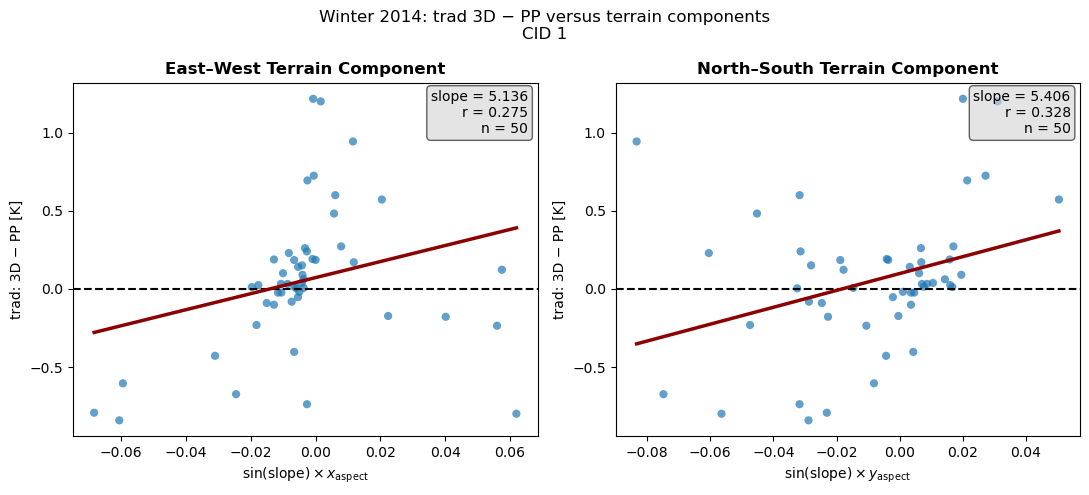


Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/terrain_test/test_CID1_Winter_2014_trad_terrain_scatter.png


In [1]:
import os
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Settings
# --------------------------------------------------
path_3d = (
    "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/"
    "upper_colorado/experiments/simulations/"
    "MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_"
    "full_domain_downscaled_test"
)

path_pp = (
    "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/"
    "upper_colorado/experiments/simulations/"
    "MSWX_3h_Snow_Project3_pp_upper_colorado_11yr_50hru_"
    "full_domain_downscaled_test"
)

outputdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/validation_plots/terrain_test"
)

cid = 1
year = 2014
season = "Winter"
season_months = [12, 1, 2]
variable = "trad"

os.makedirs(outputdir, exist_ok=True)

# --------------------------------------------------
# File paths
# --------------------------------------------------
input_3d = os.path.join(path_3d, str(cid), "input_file.nc")

output_3d = os.path.join(
    path_3d,
    "output_data",
    str(cid),
    f"{year}-01-01.nc",
)

output_pp = os.path.join(
    path_pp,
    "output_data",
    str(cid),
    f"{year}-01-01.nc",
)

for filename in [input_3d, output_3d, output_pp]:
    if not os.path.exists(filename):
        raise FileNotFoundError(filename)

# --------------------------------------------------
# Read HRU terrain parameters
# --------------------------------------------------
with nc.Dataset(input_3d) as ds:
    parameters = ds.groups["parameters"]

    slope = np.ma.asarray(
        parameters.variables["slope"][:]
    ).filled(np.nan).astype(float)

    x_aspect = np.ma.asarray(
        parameters.variables["x_aspect"][:]
    ).filled(np.nan).astype(float)

    y_aspect = np.ma.asarray(
        parameters.variables["y_aspect"][:]
    ).filled(np.nan).astype(float)

    hru = np.asarray(parameters.variables["hru"][:])

# Slope values are already in radians.
east_west = np.sin(slope) * x_aspect
north_south = np.sin(slope) * y_aspect

# --------------------------------------------------
# Read 3D and PP output
# --------------------------------------------------
with nc.Dataset(output_3d) as ds:
    trad_3d = np.ma.asarray(
        ds.groups["data"].variables[variable][:]
    ).filled(np.nan).astype(float)

with nc.Dataset(output_pp) as ds:
    trad_pp = np.ma.asarray(
        ds.groups["data"].variables[variable][:]
    ).filled(np.nan).astype(float)

print("3D shape:", trad_3d.shape)
print("PP shape:", trad_pp.shape)
print("Terrain HRUs:", slope.size)

if trad_3d.shape != trad_pp.shape:
    raise ValueError(
        f"3D and PP shape mismatch: {trad_3d.shape} versus {trad_pp.shape}"
    )

if trad_3d.ndim != 2:
    raise ValueError(
        f"Expected trad dimensions (time, hru), found {trad_3d.shape}"
    )

if trad_3d.shape[1] != slope.size:
    raise ValueError(
        f"Output has {trad_3d.shape[1]} HRUs, but terrain has "
        f"{slope.size} HRUs"
    )

# --------------------------------------------------
# Construct the 3-hourly 2014 time axis
# --------------------------------------------------
ntime = trad_3d.shape[0]

times = pd.date_range(
    start=f"{year}-01-01 00:00:00",
    periods=ntime,
    freq="3h",
)

season_mask = times.month.isin(season_months)

print("Total time steps:", ntime)
print(f"{season} time steps:", season_mask.sum())
print("First time:", times[0])
print("Last time:", times[-1])

if season_mask.sum() == 0:
    raise RuntimeError(f"No {season} time steps were selected")

# --------------------------------------------------
# Seasonal mean 3D-minus-PP difference for each HRU
# --------------------------------------------------
difference = trad_3d - trad_pp

seasonal_difference = np.nanmean(
    difference[season_mask, :],
    axis=0,
)

# --------------------------------------------------
# Diagnostics
# --------------------------------------------------
print("\nTerrain diagnostics")
print("Slope range:", np.nanmin(slope), np.nanmax(slope))
print(
    "East-west range:",
    np.nanmin(east_west),
    np.nanmax(east_west),
)
print(
    "North-south range:",
    np.nanmin(north_south),
    np.nanmax(north_south),
)
print(
    "trad difference range:",
    np.nanmin(seasonal_difference),
    np.nanmax(seasonal_difference),
)

# --------------------------------------------------
# Regression helper
# --------------------------------------------------
def regression(x, y):
    valid = np.isfinite(x) & np.isfinite(y)

    xv = x[valid]
    yv = y[valid]

    if xv.size < 2 or np.std(xv) == 0:
        return xv, yv, np.nan, np.nan, np.nan

    fit_slope, intercept = np.polyfit(xv, yv, 1)
    correlation = np.corrcoef(xv, yv)[0, 1]

    return xv, yv, fit_slope, intercept, correlation


# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

plot_information = [
    (
        axes[0],
        east_west,
        r"$\sin(\mathrm{slope})\times x_{\mathrm{aspect}}$",
        "East–West Terrain Component",
    ),
    (
        axes[1],
        north_south,
        r"$\sin(\mathrm{slope})\times y_{\mathrm{aspect}}$",
        "North–South Terrain Component",
    ),
]

for axis, predictor, xlabel, title in plot_information:
    x, y, fit_slope, intercept, correlation = regression(
        predictor,
        seasonal_difference,
    )

    axis.scatter(
        x,
        y,
        s=35,
        alpha=0.7,
        edgecolors="none",
    )

    axis.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.5,
    )

    if np.isfinite(fit_slope):
        xmin = np.min(x)
        xmax = np.max(x)
        line_x = np.linspace(xmin, xmax, 100)

        axis.plot(
            line_x,
            intercept + fit_slope * line_x,
            color="darkred",
            linewidth=2.5,
        )

    x_range = np.max(x) - np.min(x)
    x_padding = 0.05 * x_range if x_range > 0 else 0.01

    axis.set_xlim(
        np.min(x) - x_padding,
        np.max(x) + x_padding,
    )

    axis.set_title(title, fontweight="bold")
    axis.set_xlabel(xlabel)
    axis.set_ylabel("trad: 3D − PP [K]")

    axis.text(
        0.98,
        0.98,
        (
            f"slope = {fit_slope:.3f}\n"
            f"r = {correlation:.3f}\n"
            f"n = {x.size}"
        ),
        transform=axis.transAxes,
        horizontalalignment="right",
        verticalalignment="top",
        bbox={
            "boxstyle": "round",
            "facecolor": "lightgray",
            "edgecolor": "black",
            "alpha": 0.6,
        },
    )

fig.suptitle(
    f"{season} {year}: trad 3D − PP versus terrain components\n"
    f"CID {cid}"
)

plt.tight_layout()

output_file = os.path.join(
    outputdir,
    f"test_CID{cid}_{season}_{year}_trad_terrain_scatter.png",
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("\nSaved:", output_file)

CID 1: retained 50 of 50 HRUs
CID 2: retained 50 of 50 HRUs
CID 3: retained 50 of 50 HRUs
CID 4: retained 50 of 50 HRUs
CID 5: retained 50 of 50 HRUs

Combined CIDs: [1, 2, 3, 4, 5]
Total observations: 250
trad difference range: -2.0674725773358587 1.9146198311237375


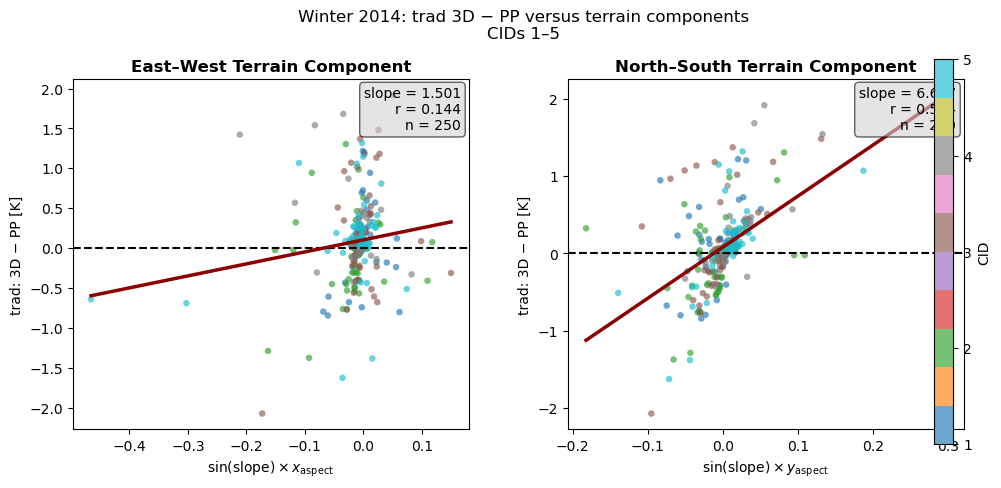

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/terrain_test/test_CID1_5_Winter_2014_trad_terrain_scatter.png


In [2]:
import os
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Settings
# --------------------------------------------------
path_3d = (
    "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/"
    "upper_colorado/experiments/simulations/"
    "MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_"
    "full_domain_downscaled_test"
)

path_pp = (
    "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/"
    "upper_colorado/experiments/simulations/"
    "MSWX_3h_Snow_Project3_pp_upper_colorado_11yr_50hru_"
    "full_domain_downscaled_test"
)

outputdir = (
    "/scratch/alpine/battobrah@xsede.org/"
    "HydroBlocks_Enrico_dev/validation_plots/terrain_test"
)

cids = [1, 2, 3, 4, 5]
year = 2014
season = "Winter"
season_months = [12, 1, 2]
variable = "trad"

os.makedirs(outputdir, exist_ok=True)

# --------------------------------------------------
# Combined HRU data
# --------------------------------------------------
east_west_all = []
north_south_all = []
difference_all = []
cid_all = []

for cid in cids:
    input_3d = os.path.join(
        path_3d,
        str(cid),
        "input_file.nc",
    )

    output_3d = os.path.join(
        path_3d,
        "output_data",
        str(cid),
        f"{year}-01-01.nc",
    )

    output_pp = os.path.join(
        path_pp,
        "output_data",
        str(cid),
        f"{year}-01-01.nc",
    )

    for filename in [input_3d, output_3d, output_pp]:
        if not os.path.exists(filename):
            raise FileNotFoundError(filename)

    # Terrain parameters
    with nc.Dataset(input_3d) as ds:
        parameters = ds.groups["parameters"]

        slope = np.ma.asarray(
            parameters.variables["slope"][:]
        ).filled(np.nan).astype(float)

        x_aspect = np.ma.asarray(
            parameters.variables["x_aspect"][:]
        ).filled(np.nan).astype(float)

        y_aspect = np.ma.asarray(
            parameters.variables["y_aspect"][:]
        ).filled(np.nan).astype(float)

    east_west = np.sin(slope) * x_aspect
    north_south = np.sin(slope) * y_aspect

    # 3D trad
    with nc.Dataset(output_3d) as ds:
        trad_3d = np.ma.asarray(
            ds.groups["data"].variables[variable][:]
        ).filled(np.nan).astype(float)

    # PP trad
    with nc.Dataset(output_pp) as ds:
        trad_pp = np.ma.asarray(
            ds.groups["data"].variables[variable][:]
        ).filled(np.nan).astype(float)

    if trad_3d.shape != trad_pp.shape:
        raise ValueError(
            f"CID {cid}: shape mismatch: "
            f"3D {trad_3d.shape}, PP {trad_pp.shape}"
        )

    if trad_3d.ndim != 2:
        raise ValueError(
            f"CID {cid}: expected (time, hru), "
            f"found {trad_3d.shape}"
        )

    if trad_3d.shape[1] != slope.size:
        raise ValueError(
            f"CID {cid}: output has {trad_3d.shape[1]} HRUs, "
            f"terrain has {slope.size}"
        )

    # Construct time axis for this annual file
    times = pd.date_range(
        start=f"{year}-01-01 00:00:00",
        periods=trad_3d.shape[0],
        freq="3h",
    )

    season_mask = times.month.isin(season_months)

    if season_mask.sum() == 0:
        raise RuntimeError(
            f"CID {cid}: no {season} time steps selected"
        )

    difference = trad_3d - trad_pp

    seasonal_difference = np.nanmean(
        difference[season_mask, :],
        axis=0,
    )

    valid = (
        np.isfinite(east_west) &
        np.isfinite(north_south) &
        np.isfinite(seasonal_difference)
    )

    east_west_all.append(east_west[valid])
    north_south_all.append(north_south[valid])
    difference_all.append(seasonal_difference[valid])
    cid_all.append(
        np.full(np.sum(valid), cid, dtype=int)
    )

    print(
        f"CID {cid}: retained {np.sum(valid)} of "
        f"{slope.size} HRUs"
    )

# Combine all CIDs
east_west_all = np.concatenate(east_west_all)
north_south_all = np.concatenate(north_south_all)
difference_all = np.concatenate(difference_all)
cid_all = np.concatenate(cid_all)

print("\nCombined CIDs:", cids)
print("Total observations:", difference_all.size)
print(
    "trad difference range:",
    difference_all.min(),
    difference_all.max(),
)

# --------------------------------------------------
# Regression helper
# --------------------------------------------------
def regression(x, y):
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    fit_slope, intercept = np.polyfit(x, y, 1)
    correlation = np.corrcoef(x, y)[0, 1]

    return x, y, fit_slope, intercept, correlation


# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

plot_information = [
    (
        axes[0],
        east_west_all,
        r"$\sin(\mathrm{slope})\times x_{\mathrm{aspect}}$",
        "East–West Terrain Component",
    ),
    (
        axes[1],
        north_south_all,
        r"$\sin(\mathrm{slope})\times y_{\mathrm{aspect}}$",
        "North–South Terrain Component",
    ),
]

for axis, predictor, xlabel, title in plot_information:
    x, y, fit_slope, intercept, correlation = regression(
        predictor,
        difference_all,
    )

    # Give each CID a different color
    scatter = axis.scatter(
        x,
        y,
        c=cid_all,
        cmap="tab10",
        s=22,
        alpha=0.65,
        edgecolors="none",
    )

    axis.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.5,
    )

    xmin = x.min()
    xmax = x.max()
    line_x = np.linspace(xmin, xmax, 100)

    axis.plot(
        line_x,
        intercept + fit_slope * line_x,
        color="darkred",
        linewidth=2.5,
    )

    x_padding = 0.05 * (xmax - xmin)
    axis.set_xlim(
        xmin - x_padding,
        xmax + x_padding,
    )

    axis.set_title(title, fontweight="bold")
    axis.set_xlabel(xlabel)
    axis.set_ylabel("trad: 3D − PP [K]")

    axis.text(
        0.98,
        0.98,
        (
            f"slope = {fit_slope:.3f}\n"
            f"r = {correlation:.3f}\n"
            f"n = {x.size}"
        ),
        transform=axis.transAxes,
        horizontalalignment="right",
        verticalalignment="top",
        bbox={
            "boxstyle": "round",
            "facecolor": "lightgray",
            "edgecolor": "black",
            "alpha": 0.6,
        },
    )

colorbar = fig.colorbar(
    scatter,
    ax=axes,
    ticks=cids,
    fraction=0.035,
    pad=0.03,
)
colorbar.set_label("CID")

fig.suptitle(
    f"{season} {year}: trad 3D − PP versus terrain components\n"
    f"CIDs {cids[0]}–{cids[-1]}"
)

fig.subplots_adjust(
    left=0.09,
    right=0.90,
    bottom=0.14,
    top=0.84,
    wspace=0.25,
)

output_file = os.path.join(
    outputdir,
    f"test_CID1_5_{season}_{year}_trad_terrain_scatter.png",
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:", output_file)

In [1]:
import netCDF4 as nc
import numpy as np
from datetime import datetime, timedelta
import glob, os

EPOCH = datetime(1970, 1, 1)

def datetime_hours(value):
    value = datetime(value.year, value.month, value.day,
                      value.hour, value.minute, value.second)
    return (value - EPOCH).total_seconds() / 3600.0

In [6]:
# EDIT THIS PATH to one real file in your postprocess/output_dir
path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test/postprocess/output_dir/20180615.nc"

basename = os.path.basename(path)
file_date = datetime.strptime(basename[:8], "%Y%m%d")
print("File date parsed from filename:", file_date)

File date parsed from filename: 2018-06-15 00:00:00


In [7]:
with nc.Dataset(path) as ds:
    tvar = ds.variables["t"]
    units = getattr(tvar, "units", None)
    calendar = getattr(tvar, "calendar", "standard")
    raw = np.asarray(tvar[:])

print("units:", units)
print("calendar:", calendar)
print("raw t values:", raw)

real_dates = nc.num2date(raw, units=units, calendar=calendar,
                          only_use_cftime_datetimes=False,
                          only_use_python_datetimes=True)
real_dates = list(np.atleast_1d(real_dates))
for i, d in enumerate(real_dates):
    print(f"slot {i}: {d.isoformat()}")

units: hours since 2014-01-01 00:00:00.0
calendar: standard
raw t values: [39024. 39025. 39026. 39027. 39028. 39029. 39030. 39031.]
slot 0: 2018-06-15T00:00:00
slot 1: 2018-06-15T01:00:00
slot 2: 2018-06-15T02:00:00
slot 3: 2018-06-15T03:00:00
slot 4: 2018-06-15T04:00:00
slot 5: 2018-06-15T05:00:00
slot 6: 2018-06-15T06:00:00
slot 7: 2018-06-15T07:00:00


In [8]:
n_slots = len(real_dates)
assumed_dates = [file_date + timedelta(hours=3*i) for i in range(n_slots)]

print(f"{'slot':<5}{'real (UTC)':<25}{'assumed (UTC)':<25}{'diff (h)':<10}")
max_diff = 0.0
for i, (real, assumed) in enumerate(zip(real_dates, assumed_dates)):
    diff = (real - assumed).total_seconds() / 3600.0
    max_diff = max(max_diff, abs(diff))
    flag = "OK" if abs(diff) < 1e-6 else "MISMATCH"
    print(f"{i:<5}{real.isoformat():<25}{assumed.isoformat():<25}{diff:+.3f}   {flag}")

print()
print("All match!" if max_diff < 1e-6 else f"MISMATCH — max offset {max_diff:.3f} hours")

slot real (UTC)               assumed (UTC)            diff (h)  
0    2018-06-15T00:00:00      2018-06-15T00:00:00      +0.000   OK
1    2018-06-15T01:00:00      2018-06-15T03:00:00      -2.000   MISMATCH
2    2018-06-15T02:00:00      2018-06-15T06:00:00      -4.000   MISMATCH
3    2018-06-15T03:00:00      2018-06-15T09:00:00      -6.000   MISMATCH
4    2018-06-15T04:00:00      2018-06-15T12:00:00      -8.000   MISMATCH
5    2018-06-15T05:00:00      2018-06-15T15:00:00      -10.000   MISMATCH
6    2018-06-15T06:00:00      2018-06-15T18:00:00      -12.000   MISMATCH
7    2018-06-15T07:00:00      2018-06-15T21:00:00      -14.000   MISMATCH

MISMATCH — max offset 14.000 hours


In [9]:
folder = "/path/to/postprocess/output_dir"
files = sorted(glob.glob(os.path.join(folder, "????????.nc")))
sample_files = [files[0], files[len(files)//2], files[-1]]  # early, middle, late

for path in sample_files:
    basename = os.path.basename(path)
    file_date = datetime.strptime(basename[:8], "%Y%m%d")
    with nc.Dataset(path) as ds:
        tvar = ds.variables["t"]
        raw = np.asarray(tvar[:])
        real_dates = nc.num2date(raw, units=tvar.units,
                                  calendar=getattr(tvar, "calendar", "standard"),
                                  only_use_cftime_datetimes=False,
                                  only_use_python_datetimes=True)
        real_dates = list(np.atleast_1d(real_dates))
    assumed = [file_date + timedelta(hours=3*i) for i in range(len(real_dates))]
    diffs = [(r - a).total_seconds()/3600 for r, a in zip(real_dates, assumed)]
    print(basename, "max diff (h):", max(abs(d) for d in diffs))

IndexError: list index out of range

In [10]:
with nc.Dataset(path) as ds:
    swdn = ds.variables["swdn"][:] if "swdn" in ds.variables else None
    print(list(ds.variables.keys()))  # confirm exact variable name if swdn isn't it

if swdn is not None:
    # average over space so you just see the diurnal shape
    swdn_mean = np.nanmean(swdn, axis=(1, 2)) if swdn.ndim == 3 else swdn
    for i, v in enumerate(swdn_mean):
        hour_if_3hourly = 3 * i
        print(f"slot {i}  (assumed hour {hour_if_3hourly:02d} UTC):  swdn = {v:.1f}")

['lon', 'lat', 't', 'trad', 'swe', 'fsno', 'swdn_3d', 'swnet', 'lwdn_3d', 'lwnet', 'smc', 'cosz', 'salb']


In [11]:
with nc.Dataset(path) as ds:
    swdn = ds.variables["swdn_3d"][:]
    print("shape:", swdn.shape)

# average over space so you just see the diurnal shape
if swdn.ndim == 3:
    swdn_mean = np.nanmean(swdn, axis=(1, 2))
else:
    swdn_mean = swdn

for i, v in enumerate(swdn_mean):
    hour_if_3hourly = 3 * i
    print(f"slot {i}  (assumed hour {hour_if_3hourly:02d} UTC):  swdn_3d = {v:.1f}")

shape: (8, 630, 630)
slot 0  (assumed hour 00 UTC):  swdn_3d = 222.0
slot 1  (assumed hour 03 UTC):  swdn_3d = 0.4
slot 2  (assumed hour 06 UTC):  swdn_3d = 0.0
slot 3  (assumed hour 09 UTC):  swdn_3d = 0.0
slot 4  (assumed hour 12 UTC):  swdn_3d = 22.2
slot 5  (assumed hour 15 UTC):  swdn_3d = 358.9
slot 6  (assumed hour 18 UTC):  swdn_3d = 555.0
slot 7  (assumed hour 21 UTC):  swdn_3d = 478.2


File: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test/postprocess/output_dir/20141201.nc
Timesteps: 8
Total valid points: 2889608
Points with cosz < 0: 1646333
Mean SWDN when cosz < 0: 0.0067586135
Maximum SWDN when cosz < 0: 1683.5139
Points with cosz < 0 and SWDN > 0: 2549
Fraction with cosz < 0 and SWDN > 0: 0.0015482894408360883


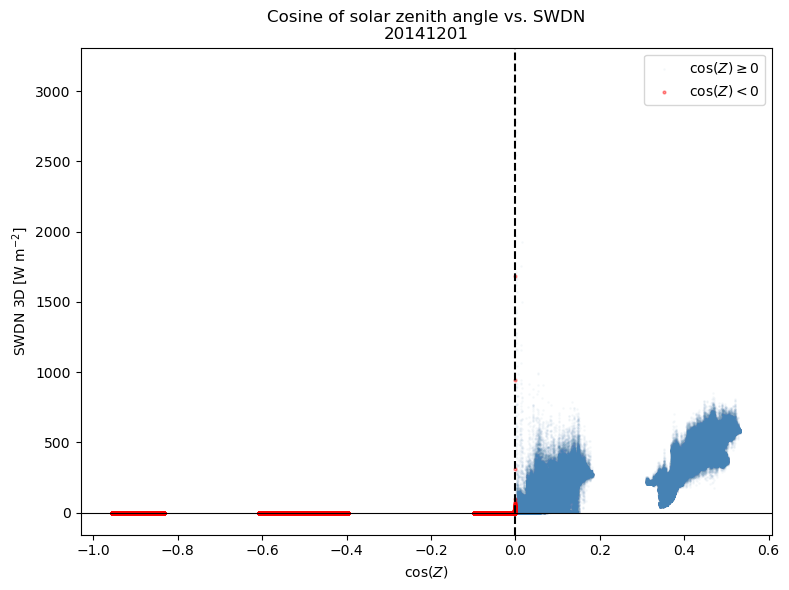

In [1]:
import os
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

EDIR = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test"
DATE = "20141201"

filename = os.path.join(EDIR, "postprocess", "output_dir", f"{DATE}.nc")

with nc.Dataset(filename) as ds:
    cosz = np.ma.asarray(ds.variables["cosz"][:]).filled(np.nan)
    swdn = np.ma.asarray(ds.variables["swdn_3d"][:]).filled(np.nan)

valid = np.isfinite(cosz) & np.isfinite(swdn)
cosz = cosz[valid]
swdn = swdn[valid]
night = cosz < 0

print("File:", filename)
print("Timesteps:", 8)
print("Total valid points:", cosz.size)
print("Points with cosz < 0:", night.sum())
print("Mean SWDN when cosz < 0:", np.mean(swdn[night]))
print("Maximum SWDN when cosz < 0:", np.max(swdn[night]))
print("Points with cosz < 0 and SWDN > 0:", np.sum(night & (swdn > 0)))
print("Fraction with cosz < 0 and SWDN > 0:", np.mean(swdn[night] > 0))

plt.figure(figsize=(8, 6))
plt.scatter(cosz[~night], swdn[~night], s=1, alpha=0.03,
            color="steelblue", label=r"$\cos(Z)\geq0$")
plt.scatter(cosz[night], swdn[night], s=4, alpha=0.4,
            color="red", label=r"$\cos(Z)<0$")

plt.axvline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel(r"$\cos(Z)$")
plt.ylabel(r"SWDN 3D [W m$^{-2}$]")
plt.title(f"Cosine of solar zenith angle vs. SWDN\n{DATE}")
plt.legend()
plt.tight_layout()
plt.show()

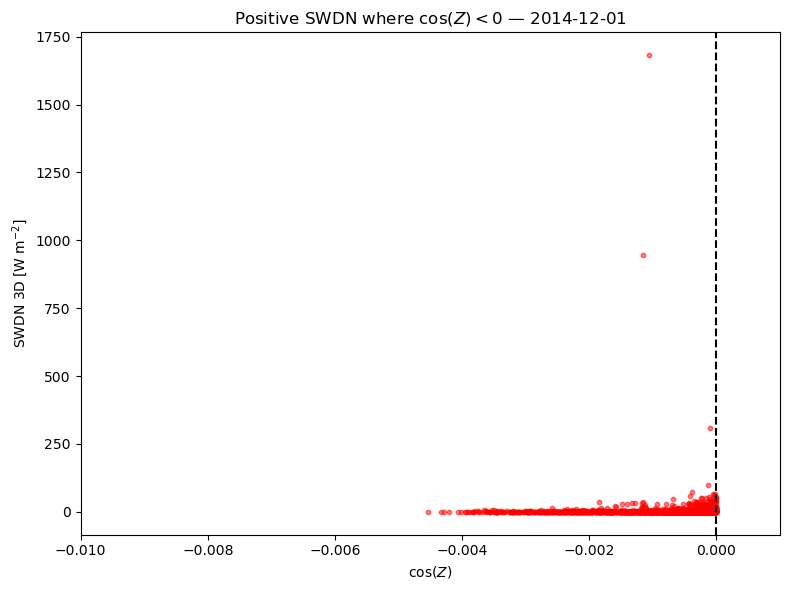

In [2]:
problem = night & (swdn > 0)

plt.figure(figsize=(8, 6))
plt.scatter(cosz[problem], swdn[problem], s=10, alpha=0.5, color="red")
plt.axvline(0, color="black", linestyle="--")
plt.xlim(-0.01, 0.001)
plt.xlabel(r"$\cos(Z)$")
plt.ylabel(r"SWDN 3D [W m$^{-2}$]")
plt.title(r"Positive SWDN where $\cos(Z)<0$ — 2014-12-01")
plt.tight_layout()
plt.show()

In [3]:
import os
import netCDF4 as nc
import numpy as np
import rasterio

EDIR = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test"

DATE = "20141201"
ROW, COL = 481, 35
DAILY_INDEX = 5                       # 15 UTC = 08 MT
RAW_INDEX = 334 * 8 + DAILY_INDEX    # December 1 is day index 334 in 2014

post_file = os.path.join(EDIR, "postprocess", "output_dir", f"{DATE}.nc")
cids_file = os.path.join(EDIR, "postprocess", "cids.vrt")
hrus_file = os.path.join(EDIR, "postprocess", "hrus.vrt")

# Obtain the geographic coordinates and postprocessed values.
with nc.Dataset(post_file) as ds:
    lon = np.asarray(ds.variables["lon"][:])
    lat = np.asarray(ds.variables["lat"][:])

    longitude = lon[COL] if lon.ndim == 1 else lon[ROW, COL]
    latitude = lat[ROW] if lat.ndim == 1 else lat[ROW, COL]

    post_cosz = ds.variables["cosz"][DAILY_INDEX, ROW, COL]
    post_swdn = ds.variables["swdn_3d"][DAILY_INDEX, ROW, COL]

# Find the CID and HRU covering that coordinate.
with rasterio.open(cids_file) as ds:
    cid = int(next(ds.sample([(longitude, latitude)]))[0])

with rasterio.open(hrus_file) as ds:
    hru_id = int(next(ds.sample([(longitude, latitude)]))[0])

print("Longitude, latitude:", longitude, latitude)
print("CID:", cid)
print("HRU ID:", hru_id)
print("Postprocessed cosz:", post_cosz)
print("Postprocessed SWDN 3D:", post_swdn)

raw_file = os.path.join(EDIR, "output_data", str(cid), "2014-01-01.nc")
input_file = os.path.join(EDIR, str(cid), "input_file.nc")

# Find the raw-array position corresponding to the mapped HRU.
with nc.Dataset(input_file) as ds:
    parameters = ds.groups["parameters"]
    raw_hru_ids = np.asarray(parameters.variables["hru"][:]).squeeze()

matches = np.where(raw_hru_ids == hru_id)[0]

if matches.size:
    hru_index = int(matches[0])
else:
    # Check whether HRU raster IDs are one-based array positions.
    hru_index = hru_id - 1

print("Raw file:", raw_file)
print("Raw HRU index:", hru_index)
print("Raw time index:", RAW_INDEX)

with nc.Dataset(raw_file) as ds:
    data = ds.groups["data"]

    print("\nAvailable raw variables:")
    print(list(data.variables))

    raw_cosz = np.asarray(data.variables["cosz"][RAW_INDEX, hru_index]).item()
    raw_swdn = np.asarray(data.variables["swdn_3d"][RAW_INDEX, hru_index]).item()

print("\nComparison")
print("Postprocessed cosz:", post_cosz)
print("Raw cosz:", raw_cosz)
print("Postprocessed SWDN 3D:", post_swdn)
print("Raw SWDN 3D:", raw_swdn)

Longitude, latitude: -113.65041666666441 41.76708333332771
CID: 1242
HRU ID: 24
Postprocessed cosz: -0.0010604858
Postprocessed SWDN 3D: 1683.5139
Raw file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test/output_data/1242/2014-01-01.nc
Raw HRU index: 24
Raw time index: 2677

Available raw variables:
['qsnow', 'qsurface', 'runoff', 'totsmc', 'swe', 'snow_t', 'snowh', 'fsno', 't2mv', 't2mb', 'swdn', 'swdn_3d', 'swnet', 'lwdn', 'lwdn_3d', 'lwnet', 'cosz', 'azimuth', 'smc', 'trad', 'salb', 'sh', 'lh', 'tv']

Comparison
Postprocessed cosz: -0.0010604858
Raw cosz: -0.00152587890625
Postprocessed SWDN 3D: 1683.5139
Raw SWDN 3D: 0.0


In [4]:
with nc.Dataset(raw_file) as ds:
    data = ds.groups["data"]
    raw_cosz_all = np.asarray(data.variables["cosz"][:])
    raw_swdn_all = np.asarray(data.variables["swdn_3d"][:])

target = float(post_swdn)

# Search the entire CID output for the closest SWDN value.
difference = np.abs(raw_swdn_all - target)
time_found, hru_found = np.unravel_index(
    np.nanargmin(difference), difference.shape
)

print("Closest raw SWDN:", raw_swdn_all[time_found, hru_found])
print("Corresponding raw cosz:", raw_cosz_all[time_found, hru_found])
print("Raw time index:", time_found)
print("Raw HRU index:", hru_found)
print("Difference from postprocessed SWDN:",
      difference[time_found, hru_found])

print("\nValues around expected time for HRU indices 23 and 24:")
for t in range(RAW_INDEX - 2, RAW_INDEX + 3):
    for h in [23, 24]:
        print(
            f"time={t}, HRU index={h}, "
            f"cosz={raw_cosz_all[t, h]:.6f}, "
            f"SWDN={raw_swdn_all[t, h]:.3f}"
        )

Closest raw SWDN: 1335.3259
Corresponding raw cosz: 0.026672363
Raw time index: 25957
Raw HRU index: 49
Difference from postprocessed SWDN: 348.188

Values around expected time for HRU indices 23 and 24:
time=2675, HRU index=23, cosz=-0.893738, SWDN=0.000
time=2675, HRU index=24, cosz=-0.893555, SWDN=0.000
time=2676, HRU index=23, cosz=-0.528809, SWDN=0.000
time=2676, HRU index=24, cosz=-0.528503, SWDN=0.000
time=2677, HRU index=23, cosz=-0.001831, SWDN=0.000
time=2677, HRU index=24, cosz=-0.001526, SWDN=0.000
time=2678, HRU index=23, cosz=0.378357, SWDN=329.284
time=2678, HRU index=24, cosz=0.378418, SWDN=293.589
time=2679, HRU index=23, cosz=0.388977, SWDN=226.304
time=2679, HRU index=24, cosz=0.388855, SWDN=199.867


In [5]:
TIME_INDEX = 2677

with nc.Dataset(raw_file) as ds:
    data = ds.groups["data"]
    cosz_50 = np.ma.asarray(data.variables["cosz"][TIME_INDEX, :]).filled(np.nan)
    swdn_50 = np.ma.asarray(data.variables["swdn_3d"][TIME_INDEX, :]).filled(np.nan)

print("HRU   cosz          SWDN 3D [W m-2]")
print("-------------------------------------")

for hru in range(len(cosz_50)):
    print(f"{hru:3d}   {cosz_50[hru]:10.6f}   {swdn_50[hru]:12.3f}")

print("\nNumber of HRUs:", len(cosz_50))
print("Minimum cosz:", np.nanmin(cosz_50))
print("Maximum cosz:", np.nanmax(cosz_50))
print("Minimum SWDN:", np.nanmin(swdn_50))
print("Maximum SWDN:", np.nanmax(swdn_50))
print("HRUs with cosz < 0 and SWDN > 0:",
      np.sum((cosz_50 < 0) & (swdn_50 > 0)))

HRU   cosz          SWDN 3D [W m-2]
-------------------------------------
  0    -0.001038          0.000
  1    -0.000610          0.000
  2    -0.001343          0.000
  3    -0.001221          0.000
  4    -0.001099          0.000
  5    -0.000610          0.000
  6    -0.000916          0.000
  7    -0.000916          0.000
  8    -0.000854          0.000
  9    -0.001282          0.000
 10     0.000671         75.086
 11     0.000916         72.792
 12     0.000610         75.758
 13     0.000366         75.899
 14     0.000549         75.123
 15     0.000488         75.020
 16     0.000427         75.925
 17     0.000793         73.772
 18     0.000793         73.697
 19    -0.000183          0.000
 20    -0.001648          0.000
 21    -0.001648          0.000
 22    -0.001709          0.000
 23    -0.001831          0.000
 24    -0.001526          0.000
 25    -0.001587          0.000
 26    -0.001587          0.000
 27    -0.001831          0.000
 28    -0.002075          0.00

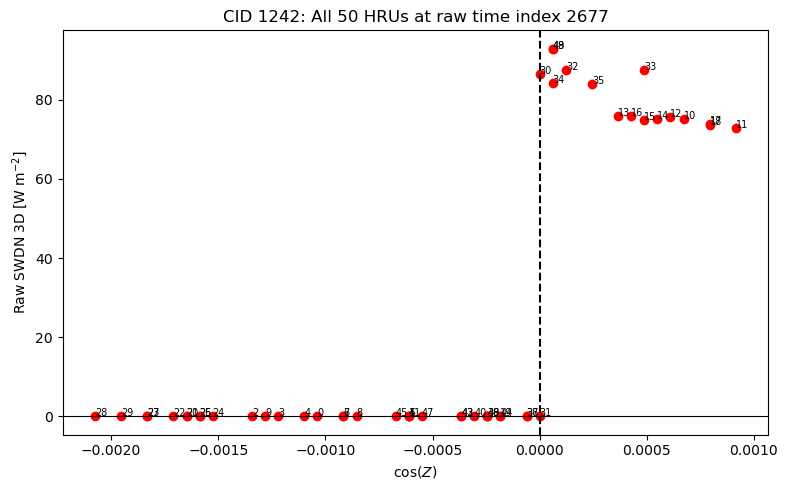

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(cosz_50, swdn_50, color="red")
plt.axvline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linewidth=0.8)

for hru, (x, y) in enumerate(zip(cosz_50, swdn_50)):
    plt.annotate(str(hru), (x, y), fontsize=7)

plt.xlabel(r"$\cos(Z)$")
plt.ylabel(r"Raw SWDN 3D [W m$^{-2}$]")
plt.title("CID 1242: All 50 HRUs at raw time index 2677")
plt.tight_layout()
plt.show()

In [2]:
for threshold in [0.01, 1.0, 10.0]:
    fraction = np.mean(swdn[night] > threshold)
    count = np.sum(swdn[night] > threshold)
    print(f"SWDN > {threshold:g} W m-2: {count:,} points ({fraction:.6%})")

SWDN > 0.01 W m-2: 1,345 points (0.256172%)
SWDN > 1 W m-2: 635 points (0.120944%)
SWDN > 10 W m-2: 124 points (0.023617%)


In [3]:
problem = night & (swdn > 1.0)

print("Number of nighttime points with SWDN > 1:", problem.sum())
print("cosz range:", cosz[problem].min(), cosz[problem].max())
print("SWDN range:", swdn[problem].min(), swdn[problem].max())

Number of nighttime points with SWDN > 1: 635
cosz range: -0.0040060426 -2.0880448e-06
SWDN range: 1.0000501 80.358475


In [4]:
import glob
import os
import netCDF4 as nc
import numpy as np
import pandas as pd

EDIR = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test"
YEAR = 2014
MONTH = 12

folder = os.path.join(EDIR, "postprocess", "output_dir")
files = sorted(glob.glob(os.path.join(folder, f"{YEAR}{MONTH:02d}??.nc")))

largest = (-np.inf, None, None, None, None)

for filename in files:
    with nc.Dataset(filename) as ds:
        cosz = np.ma.asarray(ds.variables["cosz"][:]).filled(np.nan)
        swdn = np.ma.asarray(ds.variables["swdn_3d"][:]).filled(np.nan)

    nighttime_radiation = np.where(
        (cosz < 0) & np.isfinite(cosz) & np.isfinite(swdn),
        swdn,
        -np.inf
    )

    index = np.unravel_index(np.argmax(nighttime_radiation),
                             nighttime_radiation.shape)
    value = nighttime_radiation[index]

    if value > largest[0]:
        largest = (value, filename, index, cosz[index], swdn[index])

value, filename, (time_index, row, column), cosz_at_max, swdn_at_max = largest

print("File:", filename)
print("Time index:", time_index)
print("Grid location:", row, column)
print("cosz:", cosz_at_max)
print("SWDN:", swdn_at_max)
print("Zenith angle:", np.degrees(np.arccos(cosz_at_max)))

with nc.Dataset(filename) as ds:
    cosz = np.ma.asarray(ds.variables["cosz"][:, row, column]).filled(np.nan)
    swdn = np.ma.asarray(ds.variables["swdn_3d"][:, row, column]).filled(np.nan)

    if "t" in ds.variables:
        t = ds.variables["t"]
        print("\nStored t values:", t[:])
        print("t units:", getattr(t, "units", "not available"))

date = pd.Timestamp(os.path.basename(filename)[:8], tz="UTC")
times_utc = date + pd.to_timedelta(np.arange(len(cosz)) * 3, unit="h")
times_mt = times_utc.tz_convert("America/Denver")

print("\nComplete daily time series at the maximum location:")
for i in range(len(cosz)):
    marker = " <-- maximum" if i == time_index else ""
    print(
        f"{i}: UTC={times_utc[i]}, MT={times_mt[i]}, "
        f"cosz={cosz[i]:.6f}, SWDN={swdn[i]:.3f}{marker}"
    )

File: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test/postprocess/output_dir/20141201.nc
Time index: 5
Grid location: 481 35
cosz: -0.0010604858
SWDN: 1683.5139
Zenith angle: 90.06076

Stored t values: [8016. 8017. 8018. 8019. 8020. 8021. 8022. 8023.]
t units: hours since 2014-01-01 00:00:00.0

Complete daily time series at the maximum location:
0: UTC=2014-12-01 00:00:00+00:00, MT=2014-11-30 17:00:00-07:00, cosz=0.026300, SWDN=4.197
1: UTC=2014-12-01 03:00:00+00:00, MT=2014-11-30 20:00:00-07:00, cosz=-0.501944, SWDN=0.000
2: UTC=2014-12-01 06:00:00+00:00, MT=2014-11-30 23:00:00-07:00, cosz=-0.883107, SWDN=0.000
3: UTC=2014-12-01 09:00:00+00:00, MT=2014-12-01 02:00:00-07:00, cosz=-0.894067, SWDN=0.000
4: UTC=2014-12-01 12:00:00+00:00, MT=2014-12-01 05:00:00-07:00, cosz=-0.528681, SWDN=0.000
5: UTC=2014-12-01 15:00:00+00:00, MT=2014-12-01 08:00:00-07:00, cosz=-0.001060

File: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test/postprocess/output_dir/20141201.nc
Time index: 5
Grid location: 481 35
Longitude, latitude: -113.65041666666441 41.76708333332771
cosz: -0.0010604858
SWDN: 1683.5139
Zenith angle: 90.06076137424546
Stored postprocessing timestep labels: [8016. 8017. 8018. 8019. 8020. 8021. 8022. 8023.]

Complete daily time series at the maximum location:
0: UTC=2014-12-01 00:00:00+00:00, MT=2014-11-30 17:00:00-07:00, cosz=0.026300, SWDN=4.197
1: UTC=2014-12-01 03:00:00+00:00, MT=2014-11-30 20:00:00-07:00, cosz=-0.501944, SWDN=0.000
2: UTC=2014-12-01 06:00:00+00:00, MT=2014-11-30 23:00:00-07:00, cosz=-0.883107, SWDN=0.000
3: UTC=2014-12-01 09:00:00+00:00, MT=2014-12-01 02:00:00-07:00, cosz=-0.894067, SWDN=0.000
4: UTC=2014-12-01 12:00:00+00:00, MT=2014-12-01 05:00:00-07:00, cosz=-0.528681, SWDN=0.000
5: UTC=2014-12-01 15:00:00+00:00

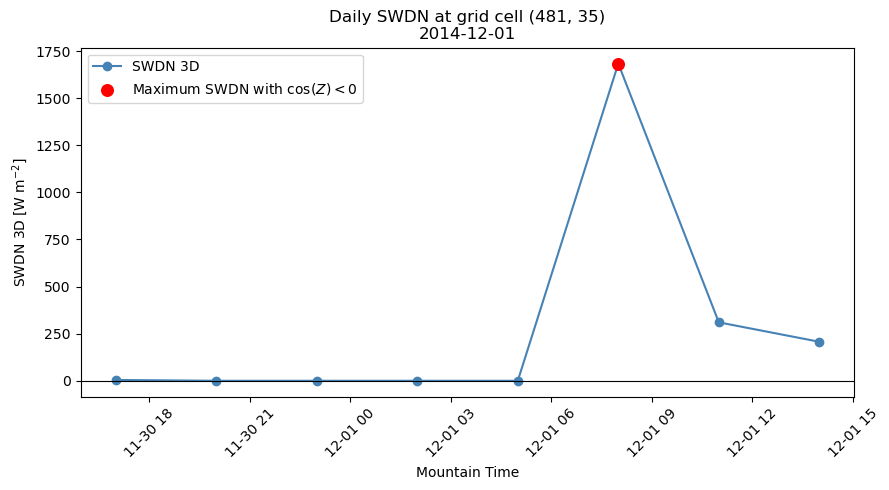

In [5]:
import glob
import os

import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import pandas as pd


EDIR = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado/experiments/simulations/MSWX_3h_Snow_Project3_3d_upper_colorado_11yr_50hru_full_domain_downscaled_test"
YEAR = 2014
MONTH = 12

folder = os.path.join(EDIR, "postprocess", "output_dir")
files = sorted(glob.glob(os.path.join(folder, f"{YEAR}{MONTH:02d}??.nc")))

if not files:
    raise FileNotFoundError(f"No postprocessed files found for {YEAR}-{MONTH:02d}")

largest = (-np.inf, None, None)

for filename in files:
    with nc.Dataset(filename) as ds:
        cosz = np.ma.asarray(ds.variables["cosz"][:]).filled(np.nan)
        swdn = np.ma.asarray(ds.variables["swdn_3d"][:]).filled(np.nan)

    nighttime_swdn = np.where(
        (cosz < 0) & np.isfinite(cosz) & np.isfinite(swdn),
        swdn,
        -np.inf
    )

    index = np.unravel_index(
        np.argmax(nighttime_swdn),
        nighttime_swdn.shape
    )
    value = nighttime_swdn[index]

    if value > largest[0]:
        largest = (value, filename, index)

maximum_swdn, filename, (time_index, row, column) = largest

if not np.isfinite(maximum_swdn):
    raise RuntimeError("No valid points with cosz < 0 were found")

with nc.Dataset(filename) as ds:
    cosz = np.ma.asarray(
        ds.variables["cosz"][:, row, column]
    ).filled(np.nan)

    swdn = np.ma.asarray(
        ds.variables["swdn_3d"][:, row, column]
    ).filled(np.nan)

    if "lon" in ds.variables and "lat" in ds.variables:
        lon = np.asarray(ds.variables["lon"][:])
        lat = np.asarray(ds.variables["lat"][:])
        longitude = lon[column]
        latitude = lat[row]
    else:
        longitude = np.nan
        latitude = np.nan

    if "t" in ds.variables:
        stored_t = np.asarray(ds.variables["t"][:])
    else:
        stored_t = None

cosz_at_max = cosz[time_index]
swdn_at_max = swdn[time_index]
zenith_at_max = np.degrees(np.arccos(np.clip(cosz_at_max, -1, 1)))

# Each daily postprocessed file contains eight 3-hourly timesteps.
date = pd.Timestamp(os.path.basename(filename)[:8], tz="UTC")
times_utc = date + pd.to_timedelta(
    np.arange(len(cosz)) * 3,
    unit="h"
)
times_mt = times_utc.tz_convert("America/Denver")

print("File:", filename)
print("Time index:", time_index)
print("Grid location:", row, column)
print("Longitude, latitude:", longitude, latitude)
print("cosz:", cosz_at_max)
print("SWDN:", swdn_at_max)
print("Zenith angle:", zenith_at_max)

if stored_t is not None:
    print("Stored postprocessing timestep labels:", stored_t)

print("\nComplete daily time series at the maximum location:")

for i in range(len(cosz)):
    marker = " <-- maximum nighttime SWDN" if i == time_index else ""

    print(
        f"{i}: UTC={times_utc[i]}, "
        f"MT={times_mt[i]}, "
        f"cosz={cosz[i]:.6f}, "
        f"SWDN={swdn[i]:.3f}"
        f"{marker}"
    )

plt.figure(figsize=(9, 5))

plt.plot(
    times_mt,
    swdn,
    marker="o",
    color="steelblue",
    label="SWDN 3D"
)

plt.scatter(
    times_mt[time_index],
    swdn_at_max,
    color="red",
    s=70,
    zorder=3,
    label=r"Maximum SWDN with $\cos(Z)<0$"
)

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Mountain Time")
plt.ylabel(r"SWDN 3D [W m$^{-2}$]")
plt.title(
    f"Daily SWDN at grid cell ({row}, {column})\n"
    f"{date.strftime('%Y-%m-%d')}"
)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
grep -RniE '(/ *COSZ|COSZ *\*\* *-1|COSZ)' \
    model/pyNoahMP/src/Noah \
    model/pyNoahMP/src/Utility_routines

SyntaxError: invalid syntax (895725344.py, line 1)

In [8]:
with nc.Dataset(filename) as ds:
    for name in ["cosz", "swdn", "swdown", "swdn_3d", "swnet"]:
        if name in ds.variables:
            value = ds.variables[name][time_index, row, column]
            print(f"{name}: {value}")
        else:
            print(f"{name}: NOT FOUND")

cosz: -0.00106048583984375
swdn: NOT FOUND
swdown: NOT FOUND
swdn_3d: 1683.513916015625
swnet: 1269.8228759765625


In [9]:
import rasterio

cids_path = os.path.join(EDIR, "postprocess", "cids.vrt")

with rasterio.open(cids_path) as src:
    cid = next(src.sample([(longitude, latitude)]))[0]

print("CID:", int(cid))

CID: 1242
